## **K-Means Clustering**

O **K-Means** é um algoritmo de **aprendizado não supervisionado** usado principalmente para **clusterização**.

Dado um conjunto de observações

$$
\mathcal{D} = \{\mathbf{x}_i\}_{i=1}^{N}
\quad \text{onde}
\quad \mathbf{x}_i \in \mathbb{R}^{D}
$$

Nosso objetivo é, dado um $k \leq N$, dividir $\mathcal{D}$ em $k$ subconjuntos, ou seja

$$
\{\mathcal{S}_{i}\}_{i=1}^{k}
$$

tal que

*   $\mathcal{S}_{i} \neq \emptyset$
*   $\mathcal{S}_{i} \cap \mathcal{S}_{j} = \emptyset \quad \forall i \neq j$
*   $\displaystyle\bigcup_{i = 1}^{k} \mathcal{S}_{i} = \mathcal{D}$

Dessa forma, para $t = \{1, 2, 3, \cdots\}$, vamos construir $\mathcal{S}_{i}^{(t)}$ da seguinte forma:

$$
\mathcal{S}_{i}^{(t)} = \{\mathbf{x} \in \mathcal{D} : \lVert \mathbf{x} - \boldsymbol{\mu}_{i}^{(t)} \rVert^{2} \leq \lVert \mathbf{x} - \boldsymbol{\mu}_{j}^{(t)} \rVert^{2} \quad \forall j \neq i \}
$$

onde os centróides são dados por

$$
\boldsymbol{\mu}_{i}^{(t+1)} = \dfrac{1}{|\mathcal{S}_{i}^{(t)}|} \cdot \sum_{\mathbf{x} \in \mathcal{S}_{i}^{(t)}} \mathbf{x}
$$

e os valores de $\boldsymbol{\mu}_{i}^{(0)}$ podem ser dados pelo *Forgy Method:*

$$
\{\boldsymbol{\mu}_{i}^{(0)}\}_{i = 1}^{k} \subset \mathcal{D}
$$

O algoritmo é repetido até que ocorra a estabilização dos *clusters:*

$$
\mathcal{S}_{i}^{(t+1)} = \mathcal{S}_{i}^{(t)}  \quad \forall i \leq k
$$

## **Aplicação do K-Means Clustering**

Vamos utilizar o algoritmo **K-Means** para **clusterização** no dataset [**Wine Recognition**](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html).

### **Pré-processamento dos dados**

In [37]:
from sklearn.datasets import load_wine

wine = load_wine()

X = wine.data

print("Shape de X:", X.shape)

Shape de X: (178, 13)


In [38]:
import pandas as pd

df = pd.DataFrame(wine.data, columns=wine.feature_names)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### **Funções auxiliares para o K-Means**

In [39]:
import numpy as np

def squaredEuclidean(x, u):
    return np.linalg.norm(x - u) ** 2

def forgyMethod(X, k):
  indices = np.random.choice(len(X), size=k, replace=False)
  return np.array(X)[indices]

def recalculateCentroids(S, k):
    newCentroids = []

    for i in range(k):
        cluster = np.array(S[i])
        mean = np.mean(cluster, axis=0)
        newCentroids.append(mean)

    return np.array(newCentroids)

def assignClusters(X, centroids):
  k = len(centroids)
  S = [[] for _ in range(k)]

  for x in X:
      distances = [squaredEuclidean(x, u) for u in centroids]
      i = np.argmin(distances)
      S[i].append(x)

  return S

def convergence(S, newS):
    return all(
        np.array_equal(np.array(S[i]), np.array(newS[i]))
        for i in range(len(S))
    )

### **Implementação do K-Means**

In [40]:
def kMeans(X, k, max_iters=100):

    c0 = forgyMethod(X, k)

    S = None

    for _ in range(max_iters):
        newS = assignClusters(X, c0)

        if S is not None and convergence(S, newS):
            break

        S = newS
        centroids = recalculateCentroids(S, k)

    return c0, centroids, S

### **Aplicação do K-Means para o conjunto de dados**

In [41]:
k = 3

centroids_init, centroids, clusters = kMeans(X, k)

### **Vizualização dos dados com PCA**

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

#### **Dados com Centroides Iniciais ($\boldsymbol{\mu}^{(0)}$)**

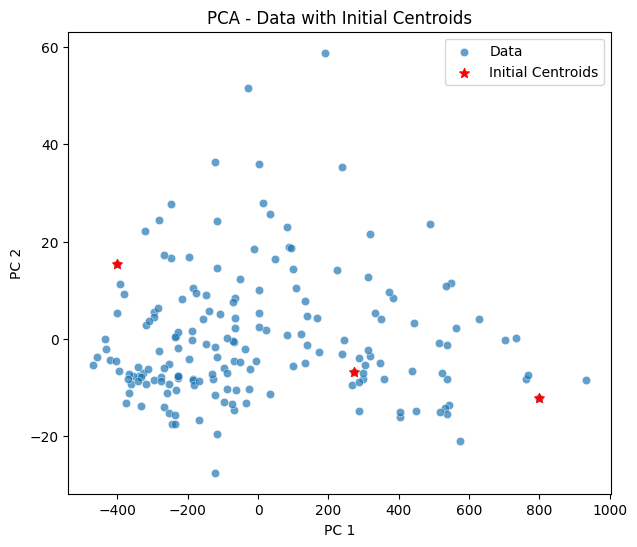

In [43]:
import matplotlib.pyplot as plt

centroids_init_pca = pca.transform(centroids_init)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(X_pca[:, 0], X_pca[:, 1], edgecolors="white", linewidths=0.4, alpha=0.7, label="Data")
ax.scatter(centroids_init_pca[:, 0], centroids_init_pca[:, 1], color="red", marker="*", s=50, label="Initial Centroids")

ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("PCA - Data with Initial Centroids")
ax.legend()

plt.show()

#### **Dados Clusterizados**

In [44]:
labels = np.zeros(len(X))

for i, cluster in enumerate(clusters):
    for point in cluster:
        index = np.where((X == point).all(axis=1))[0][0]
        labels[index] = i

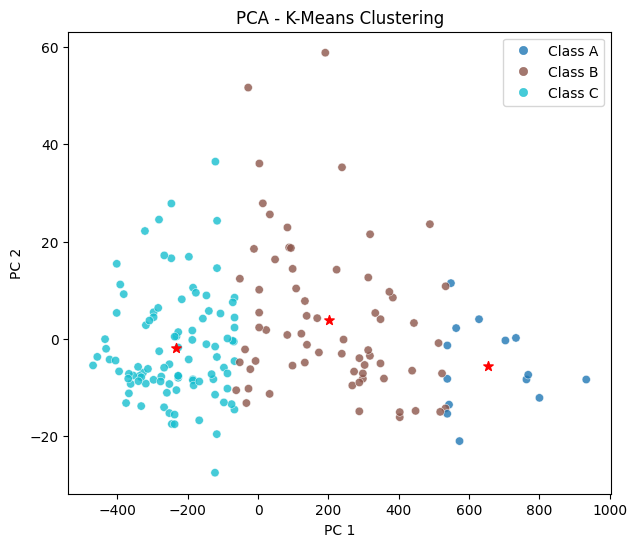

In [45]:
centroids_pca = pca.transform(centroids)

class_names = ["Class A", "Class B", "Class C"]

fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels,
                     cmap="tab10", edgecolors="white", linewidths=0.4, alpha=0.8)

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    c="red",
    marker="*",
    s=50,
    label="Centroids"
)

handles, _ = scatter.legend_elements()
ax.legend(handles, class_names)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("PCA - K-Means Clustering")

plt.show()